In [68]:
import pandas as pd 
# import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [54]:
df = pd.read_csv("housing.csv")

In [55]:
x=df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']]
y=df['median_house_value']


In [56]:
df = df.ffill()

In [57]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.5673,34.2588,28.0,3896.0,3925.0,6461.0,44.0,14.1670,254580.0,NEAR OCEAN
1,-114.5175,37.6481,7.0,334.0,1660.0,6415.0,4958.0,14.3397,180334.0,NEAR OCEAN
2,-116.8141,40.7930,35.0,9220.0,2973.0,15499.0,2858.0,4.3507,413581.0,<1H OCEAN
3,-118.2141,39.4561,28.0,3707.0,3932.0,742.0,757.0,9.7376,493833.0,NEAR BAY
4,-122.8618,40.1623,14.0,8143.0,3271.0,1528.0,199.0,7.6371,461811.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
644,-123.2425,33.3467,48.0,341.0,4369.0,11925.0,5191.0,1.3303,255704.0,INLAND
645,-115.1495,39.6751,12.0,2768.0,833.0,17019.0,5428.0,6.7923,319580.0,<1H OCEAN
646,-118.2673,33.7133,38.0,902.0,999.0,5873.0,3881.0,5.1895,398857.0,NEAR OCEAN
647,-117.3694,40.3476,1.0,5159.0,3989.0,12012.0,5765.0,11.4735,469970.0,INLAND


In [57]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.5673,34.2588,28.0,3896.0,3925.0,6461.0,44.0,14.1670,254580.0,NEAR OCEAN
1,-114.5175,37.6481,7.0,334.0,1660.0,6415.0,4958.0,14.3397,180334.0,NEAR OCEAN
2,-116.8141,40.7930,35.0,9220.0,2973.0,15499.0,2858.0,4.3507,413581.0,<1H OCEAN
3,-118.2141,39.4561,28.0,3707.0,3932.0,742.0,757.0,9.7376,493833.0,NEAR BAY
4,-122.8618,40.1623,14.0,8143.0,3271.0,1528.0,199.0,7.6371,461811.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
644,-123.2425,33.3467,48.0,341.0,4369.0,11925.0,5191.0,1.3303,255704.0,INLAND
645,-115.1495,39.6751,12.0,2768.0,833.0,17019.0,5428.0,6.7923,319580.0,<1H OCEAN
646,-118.2673,33.7133,38.0,902.0,999.0,5873.0,3881.0,5.1895,398857.0,NEAR OCEAN
647,-117.3694,40.3476,1.0,5159.0,3989.0,12012.0,5765.0,11.4735,469970.0,INLAND


In [59]:
df.drop(columns=["ocean_proximity"],inplace=True)

In [60]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-120.5673,34.2588,28.0,3896.0,3925.0,6461.0,44.0,14.1670,254580.0
1,-114.5175,37.6481,7.0,334.0,1660.0,6415.0,4958.0,14.3397,180334.0
2,-116.8141,40.7930,35.0,9220.0,2973.0,15499.0,2858.0,4.3507,413581.0
3,-118.2141,39.4561,28.0,3707.0,3932.0,742.0,757.0,9.7376,493833.0
4,-122.8618,40.1623,14.0,8143.0,3271.0,1528.0,199.0,7.6371,461811.0
...,...,...,...,...,...,...,...,...,...
644,-123.2425,33.3467,48.0,341.0,4369.0,11925.0,5191.0,1.3303,255704.0
645,-115.1495,39.6751,12.0,2768.0,833.0,17019.0,5428.0,6.7923,319580.0
646,-118.2673,33.7133,38.0,902.0,999.0,5873.0,3881.0,5.1895,398857.0
647,-117.3694,40.3476,1.0,5159.0,3989.0,12012.0,5765.0,11.4735,469970.0


In [43]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,649.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000
mean,-119.283596,37.364091,26.234568,4948.407407,2563.819444,9862.421296,3079.004630,7.924600,267602.169753
std,3.117050,2.788954,14.666954,2790.936737,1435.962821,5797.797495,1754.764842,4.138685,127697.862842
min,-124.446900,32.546900,1.000000,118.000000,66.000000,110.000000,24.000000,1.008800,50801.000000
25%,-121.984600,34.765475,14.000000,2632.250000,1301.750000,5078.250000,1481.000000,4.322400,158240.000000
50%,-119.160000,37.566150,26.000000,4685.000000,2557.500000,9543.500000,3164.500000,8.010200,260498.500000
75%,-116.571100,39.732775,39.000000,7454.250000,3843.250000,15074.250000,4564.500000,11.265450,375218.250000
max,-114.003000,41.994400,51.000000,9989.000000,4997.000000,19994.000000,5992.000000,14.997900,497127.000000


In [44]:
df['ocean_proximity'].value_counts()

ocean_proximity
NEAR BAY      148
<1H OCEAN     143
NEAR OCEAN    130
INLAND        117
ISLAND        110
Name: count, dtype: int64

In [47]:
#import matplotlib.pyplot as plt

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

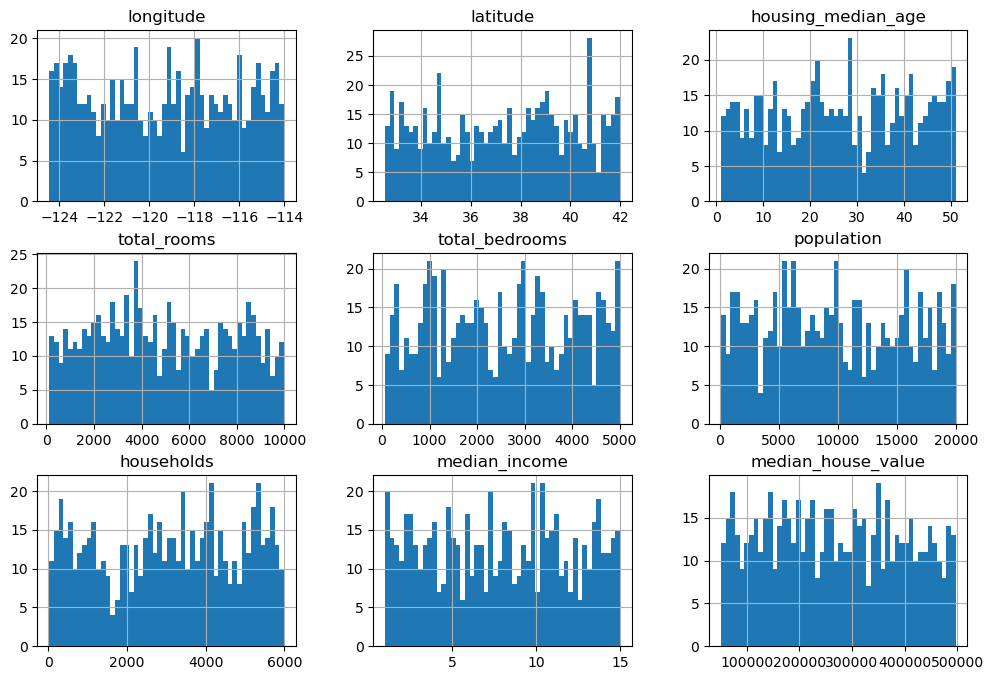

In [48]:
df.hist(bins=50,figsize=(12,8))

In [75]:
 X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
 )

In [76]:
# def shuffle_and_split(data, test_ratio):
#     shuffled_indices = np.random.permutation(len(data))
#     test_set_size = int(len(data)*test_ratio)
#     test_indices = shuffled_indices[:test_set_size]
#     train_indices = shuffled_indices[test_set_size:]
#     return data.iloc[train_indices], data.iloc[test_indices]

In [77]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [78]:
x=df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']]
y=df['median_house_value']


In [79]:
model = LinearRegression()

In [80]:
model.fit(X_train, y_train)

LinearRegression()

In [81]:
z=model.predict([[-120.5673	,34.2588,	28.0,	3896.0	,3925.0	,6461.0	,44.0	,14.1670]])	

C:\Users\visha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [82]:
print(z)

[282295.35183176]


In [84]:
print("r2_score:",r2_score(y_test,model.predict(X_test)))

r2_score: -0.007944671893615807
